# Data Analysis Template for Semantic Segmentation (Deep Learning)

## Scope
This notebook is a complete, high-standard template for image data analysis before training a semantic segmentation model.
It is designed so you can fill in the implementation step by step.

## Dataset Assumptions
- Input channels (8): **NIR, Red, Green, Blue, nDSM, Intensity, Number_of_Returns, NDVI**
- Target classes (8):
  1. Building
  2. Impervious_Surface
  3. Cropland
  4. Intensive_Culture
  5. Grassland_Garden
  6. Tree_Canopy
  7. Water
  8. Railway

## How To Use This Template
1. Keep all sections and fill each code cell marked with `TODO`.
2. Save every intermediate result to make experiments reproducible.
3. At the end, summarize findings in a short model-readiness report.

## Expected Output Artifacts
- Dataset inventory and integrity checks
- Channel statistics and class distribution reports
- Correlation matrix and feature-importance analysis
- Data-quality and risk assessment for model training

In [16]:
# ================================================
# TODO: Environment setup and imports
# ================================================

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import os
import rasterio
import re
from pathlib import Path
from cycler import cycler

# --- 1. Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

# --- 2. Plot style + Unified Color Schema ---
plt.style.use('dark_background')

# Alternativen wÃƒÂ¤ren "Set2" (etwas pastelliger) oder "Dark2" (dunkler).
NUM_CLASSES = 8
plot_palette = sns.color_palette("tab10", n_colors=NUM_CLASSES)

PALETTE_HEX = plot_palette.as_hex()

MASK_CMAP = ListedColormap(plot_palette)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.alpha": 0.35,
    "axes.prop_cycle": cycler(color=PALETTE_HEX),
})

# Seaborn auf dieselbe Palette zwingen
sns.set_palette(PALETTE_HEX)

# --- 3. Global analysis settings ---
CONFIG = {
    "SAMPLE_SIZE": 100000,
    "HIST_BINS": 100,
    "VMAX_IMAGE": 6500,
    "OUTPUT_DIR": "./reports/figures",
    "CLASS_NAMES": {
        1: "Building",
        2: "Impervious_Surface",
        3: "Cropland",
        4: "Intensive_Culture",
        5: "Grassland_Garden",
        6: "Tree_Canopy",
        7: "Water",
        8: "Railway",
    },
    "CMAP_IMAGE": "gray",
    "CMAP_MASK": MASK_CMAP,  # Nun perfekt synchronisiert mit den Plots!
    "PALETTE": PALETTE_HEX,
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [17]:
# ================================================
# Shared data loading (run once)
# ================================================

root_path = "A:/STUDIUM/06_Fruelingssemester26/BA/"

# Resolve image folder robustly (base folder changed during preprocessing).
images_base = os.path.join(root_path, "data/aerial/Buffered_images/images")
image_candidates = [
    images_base,
    os.path.join(images_base, "layer_stacks_enriched"),
    os.path.join(images_base, "NIR_RGB_nDSM"),
]
images_path = None
for cand in image_candidates:
    if os.path.isdir(cand) and any(f.lower().endswith(".tif") for f in os.listdir(cand)):
        images_path = cand
        break
if images_path is None:
    images_path = images_base

# Resolve mask folder robustly (Masks vs masks).
masks_candidates = [
    os.path.join(root_path, "data/aerial/Buffered_images/Masks"),
    os.path.join(root_path, "data/aerial/Buffered_images/masks"),
]
masks_path = None
for cand in masks_candidates:
    if os.path.isdir(cand) and any(f.lower().endswith(".tif") for f in os.listdir(cand)):
        masks_path = cand
        break
if masks_path is None:
    masks_path = masks_candidates[0]

img_files = sorted([os.path.join(images_path, f) for f in os.listdir(images_path) if f.lower().endswith(".tif")])
mask_files = sorted([os.path.join(masks_path, f) for f in os.listdir(masks_path) if f.lower().endswith(".tif")])

def tile_id(file_path):
    s = Path(file_path).stem.lower()
    s = re.sub(r"^(clipped_stacked_buffered_|mask_)", "", s)
    return s

image_arrays = {}
mask_arrays = {}
image_meta = {}
mask_meta = {}

def _load_image(file_path):
    with rasterio.open(file_path) as src:
        arr = src.read().transpose(1, 2, 0)
        meta = {
            "crs": src.crs,
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "transform": src.transform,
            "bounds": src.bounds,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
        }
    return arr, meta

def _load_mask(file_path):
    with rasterio.open(file_path) as src:
        arr = src.read(1)
        meta = {
            "crs": src.crs,
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "transform": src.transform,
            "bounds": src.bounds,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
        }
    return arr, meta

for p in img_files:
    arr, meta = _load_image(p)
    image_arrays[p] = arr
    image_meta[p] = meta

for p in mask_files:
    arr, meta = _load_mask(p)
    mask_arrays[p] = arr
    mask_meta[p] = meta

# Keep original rasterio.open and route future opens to in-memory cache.
if "_rasterio_open_original" not in globals():
    _rasterio_open_original = rasterio.open

class _CachedRaster:
    def __init__(self, path):
        self.path = path
        if path in image_arrays:
            self._is_image = True
            self._arr = image_arrays[path]
            self._meta = image_meta[path]
        elif path in mask_arrays:
            self._is_image = False
            self._arr = mask_arrays[path]
            self._meta = mask_meta[path]
        else:
            raise FileNotFoundError(path)

        self.crs = self._meta["crs"]
        self.width = self._meta["width"]
        self.height = self._meta["height"]
        self.count = self._meta["count"]
        self.transform = self._meta["transform"]
        self.bounds = self._meta["bounds"]
        self.nodata = self._meta["nodata"]
        self.dtypes = [self._meta["dtype"]] * self.count

    def read(self, indexes=None):
        if self._is_image:
            chw = self._arr.transpose(2, 0, 1)
            if indexes is None:
                return chw
            if isinstance(indexes, int):
                return chw[indexes - 1]
            return chw[np.array(indexes) - 1]

        # Mask behaves like single-band raster.
        if indexes is None:
            return self._arr[np.newaxis, :, :]
        if isinstance(indexes, int):
            if indexes != 1:
                raise IndexError("Mask has only one band")
            return self._arr
        if list(indexes) == [1]:
            return self._arr[np.newaxis, :, :]
        raise IndexError("Mask has only one band")

    def close(self):
        return None

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc, tb):
        return False

def _cached_open(path, *args, **kwargs):
    p = str(path)
    if p in image_arrays or p in mask_arrays:
        return _CachedRaster(p)
    return _rasterio_open_original(path, *args, **kwargs)

rasterio.open = _cached_open

print(
    f"Loaded files: images={len(img_files)} | masks={len(mask_files)} | "
    f"image_arrays={len(image_arrays)} | mask_arrays={len(mask_arrays)} | "
    f"images_path={images_path} | masks_path={masks_path} | rasterio_cached=True"
)

Loaded files: images=4 | masks=4 | image_arrays=4 | mask_arrays=4 | images_path=A:/STUDIUM/06_Fruelingssemester26/BA/data/aerial/Buffered_images/images | masks_path=A:/STUDIUM/06_Fruelingssemester26/BA/data/aerial/Buffered_images/Masks | rasterio_cached=True


## Notebook Roadmap

This template is organized into the following analysis blocks:
1. Dataset inventory and integrity
2. Raster metadata and geospatial consistency
3. Visual sanity checks
4. Descriptive statistics (channels and labels)
5. Missing data and NoData quality
6. Correlation matrix and feature redundancy
7. Feature importance for model-relevant signals
8. Split quality, leakage checks, and robustness
9. Outlier and hard-case mining
10. Final model-readiness report

For each code cell: replace TODO comments with your implementation and save outputs.

## 1) Dataset Inventory and Integrity

**Goal:** prove that raw data is complete, uniquely paired, and technically readable before any modeling.

### Minimum checks
- File counts and image-mask pairing
- Duplicate file detection (name and content hash)
- Corrupt/unreadable file detection
- Resolution consistency and expected channel count
- Class-ID validity in masks (expected: 1 to 8)

In [18]:
# Compact example: pair-level inventory dataframe


# Uses file lists loaded once in the shared data-loading cell

def readable(file_path, cache_dict):
    return file_path is not None and pd.notna(file_path) and file_path in cache_dict

image_df = pd.DataFrame({"image_file": img_files})
image_df["tile_id"] = image_df["image_file"].map(tile_id)

mask_df = pd.DataFrame({"mask_file": mask_files})
mask_df["tile_id"] = mask_df["mask_file"].map(tile_id)

pair_df = image_df.merge(mask_df, on="tile_id", how="outer", indicator=True)
pair_df["pair_status"] = pair_df["_merge"].map({"both": "ok", "left_only": "missing_mask", "right_only": "missing_image"})
pair_df = pair_df.drop(columns=["_merge"])

pair_df["image_file_size"] = pair_df["image_file"].map(lambda f: os.path.getsize(f) if pd.notna(f) else np.nan)
pair_df["mask_file_size"] = pair_df["mask_file"].map(lambda f: os.path.getsize(f) if pd.notna(f) else np.nan)
pair_df["is_readable"] = pair_df["image_file"].map(lambda p: readable(p, image_arrays)) & pair_df["mask_file"].map(lambda p: readable(p, mask_arrays))

dup_img = int(image_df["tile_id"].duplicated(keep=False).sum())
dup_mask = int(mask_df["tile_id"].duplicated(keep=False).sum())
summary = pair_df["pair_status"].value_counts().to_dict()

print(
    f"pairs={len(pair_df)} | ok={summary.get('ok', 0)} | "
    f"missing_mask={summary.get('missing_mask', 0)} | missing_image={summary.get('missing_image', 0)} | "
    f"dup_img={dup_img} | dup_mask={dup_mask}"
)

display(pair_df.head(10))

# Optional
# pair_df.to_csv("pair_inventory.csv", index=False)

pairs=4 | ok=4 | missing_mask=0 | missing_image=0 | dup_img=0 | dup_mask=0


,image_file,tile_id,mask_file,pair_status,image_file_size,mask_file_size,is_readable
0,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,21,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,2660312749,162849874,True
1,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,22,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,1921820677,130865788,True
2,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,24,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,2608628707,158864596,True
3,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,25,A:/STUDIUM/06_Fruelingssemester26/BA/data/aeri...,ok,2071120445,133147136,True


### Example: Why this pair-level dataframe is useful

This table is your dataset inventory.
Each row represents one tile pair candidate and tells you immediately:
- if both files exist
- if both files are readable
- if file sizes look suspicious
- if pairing by tile_id worked

You can run this once at the beginning and reuse the result for all later quality checks.

## 2) Raster Metadata and Geospatial Consistency

**Goal:** ensure geospatial compatibility across all inputs and labels.

### Minimum checks
- CRS consistency
- Pixel size / resolution consistency
- Transform and spatial extent overlap
- NoData definitions
- Data type consistency (image and mask)

This is critical for avoiding hidden alignment errors during training.

In [19]:
# Metadata comparison: image vs mask per tile_id

def get_cached_metadata(paths, file_col, meta_cache):
    rows = []
    for file in paths:
        m = meta_cache.get(file)
        if m is None:
            m = meta_cache.get(file.replace("/", "\\"))
        if m is None:
            m = meta_cache.get(file.replace("\\", "/"))
        if m is None:
            continue

        rows.append({
            "tile_id": tile_id(file),
            file_col: file,
            "crs": m["crs"],
            "width": m["width"],
            "height": m["height"],
            "count": m["count"],
            "transform": m["transform"],
            "bounds": m["bounds"],
            "dtype": m["dtype"],
            "nodata": m["nodata"],
        })
    return pd.DataFrame(rows)

def tuple_close(a, b, tol=1e-6):
    if not isinstance(a, (tuple, list)) or not isinstance(b, (tuple, list)) or len(a) != len(b):
        return False
    return all(abs(float(x) - float(y)) <= tol for x, y in zip(a, b))

img_meta = get_cached_metadata(img_files, "image_file", image_meta)
mask_meta_df = get_cached_metadata(mask_files, "mask_file", mask_meta)

meta_cmp = img_meta.merge(mask_meta_df, on="tile_id", how="outer", suffixes=("_img", "_mask"), indicator=True)
meta_cmp["pair_status"] = meta_cmp["_merge"].map({"both": "ok", "left_only": "missing_mask", "right_only": "missing_image"})

meta_cmp["same_crs"] = meta_cmp["crs_img"] == meta_cmp["crs_mask"]
meta_cmp["same_size"] = (meta_cmp["width_img"] == meta_cmp["width_mask"]) & (meta_cmp["height_img"] == meta_cmp["height_mask"])
meta_cmp["same_transform"] = [tuple_close(a, b, tol=1e-6) for a, b in zip(meta_cmp["transform_img"], meta_cmp["transform_mask"])]
meta_cmp["same_bounds"] = [tuple_close(a, b, tol=1e-3) for a, b in zip(meta_cmp["bounds_img"], meta_cmp["bounds_mask"])]

meta_cmp["meta_ok"] = (
    (meta_cmp["pair_status"] == "ok")
    & meta_cmp["same_crs"]
    & meta_cmp["same_size"]
    & meta_cmp["same_transform"]
    & meta_cmp["same_bounds"]
)

metadata_issues = meta_cmp[~meta_cmp["meta_ok"]].copy()

print(f"metadata_pairs={len(meta_cmp)} | ok={int(meta_cmp['meta_ok'].sum())} | issues={len(metadata_issues)}")
display(metadata_issues[[
    "tile_id", "pair_status",
    "same_crs", "same_size", "same_transform", "same_bounds",
    "image_file", "mask_file"
]].head(20))

metadata_pairs=4 | ok=4 | issues=0


,tile_id,pair_status,same_crs,same_size,same_transform,same_bounds,image_file,mask_file


## 3) Visual Sanity Checks (Image-Label Quality)

**Goal:** detect obvious issues early (misalignment, label noise, edge artifacts, invalid classes).

### Recommended plots
- RGB and NIR composites
- Height map visualization
- Mask-only visualization with class legend
- Image + mask overlay
- Zoom-in panels for boundaries and small objects

Prioritize difficult structures: trees, roof edges, rail lines, and water boundaries.

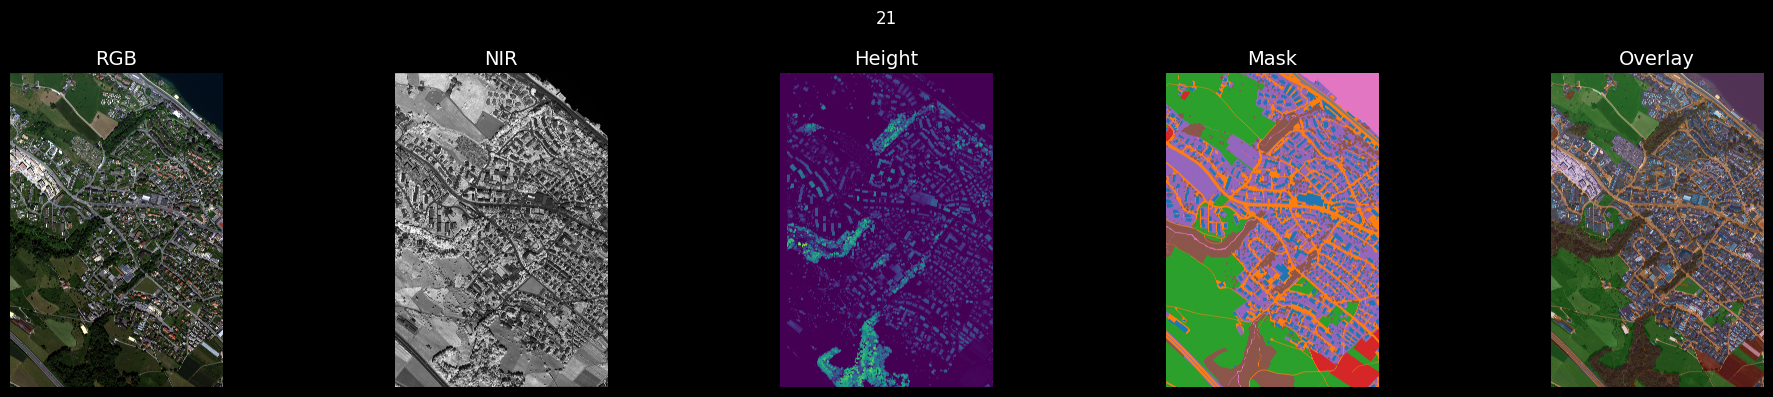

In [20]:
# Visual sanity check (compact)

required = ["img_files", "mask_files", "tile_id"]

n_samples = 1
rng = np.random.default_rng(42)

mask_lookup = {tile_id(p): p for p in mask_files}
sample_img_files = rng.choice(img_files, size=min(n_samples, len(img_files)), replace=False)

def normalize_rgb(rgb):
    rgb = rgb.astype(np.float32)
    lo = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

for img_file in sample_img_files:
    t_id = tile_id(img_file)
    mask_file = mask_lookup.get(t_id)
    if mask_file is None:
        continue

    img = image_arrays[img_file]  # (H, W, C)
    m = mask_arrays[mask_file]    # (H, W)

    rgb = normalize_rgb(img[:, :, 1:4])
    nir_raw = img[:, :, 0].astype(np.float32)
    lo, hi = np.percentile(nir_raw[nir_raw > 0], [1, 99]) if np.any(nir_raw > 0) else (nir_raw.min(), nir_raw.max())
    nir = np.clip((nir_raw - lo) / (hi - lo + 1e-6), 0, 1)
    h = img[:, :, 4] if img.shape[2] > 4 else None

    ncols = 5 if h is not None else 4
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    axes[1].imshow(nir, cmap=CONFIG["CMAP_IMAGE"])
    axes[1].set_title("NIR")
    axes[1].axis("off")

    k = 2
    if h is not None:
        axes[2].imshow(h, cmap="viridis")
        axes[2].set_title("Height")
        axes[2].axis("off")
        k = 3

    axes[k].imshow(m, cmap=CONFIG["CMAP_MASK"], vmin=1, vmax=8)
    axes[k].set_title("Mask")
    axes[k].axis("off")

    axes[k + 1].imshow(rgb)
    axes[k + 1].imshow(m, cmap=CONFIG["CMAP_MASK"], vmin=1, vmax=8, alpha=0.35)
    axes[k + 1].set_title("Overlay")
    axes[k + 1].axis("off")

    fig.suptitle(t_id)
    plt.tight_layout()
    fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], f"image_sanity_check.png"), bbox_inches="tight", facecolor="auto", dpi=150)

plt.show()

images=4 | channels=8


,channel,mean,std,min,max,p5,p50,p95
0,NIR,2675.096,1832.253,0.0,65535.0,138.0,2459.5,5774.05
1,Red,1181.213,1103.525,0.0,65535.0,280.0,879.0,2816.10
2,Green,1537.496,1126.106,0.0,65535.0,552.0,1338.0,3102.05
3,Blue,1436.553,1016.255,0.0,65535.0,749.0,1101.0,2848.00
4,nDSM,361.371,703.058,0.0,6583.0,0.0,12.0,2036.05
5,Intensity,33540.994,14952.783,0.0,65215.0,0.0,38418.0,47048.00
6,Number_of_Returns,1.709,1.722,0.0,12.0,0.0,1.0,6.00
7,NDVI,6349.300,2026.194,0.0,9999.0,2941.0,6740.5,8848.00


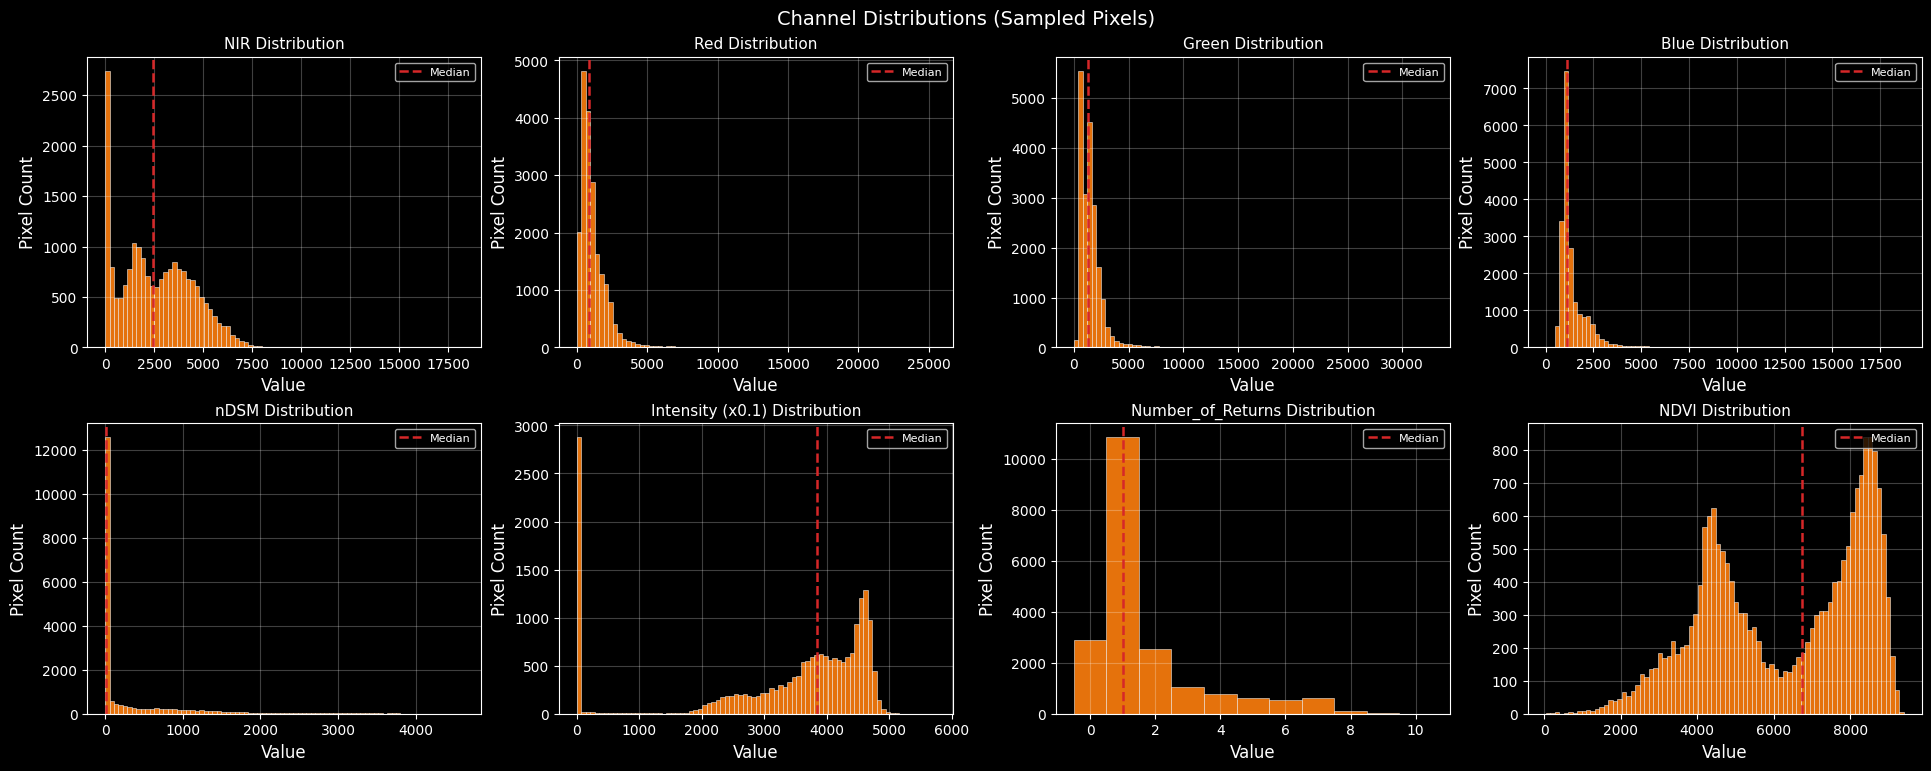

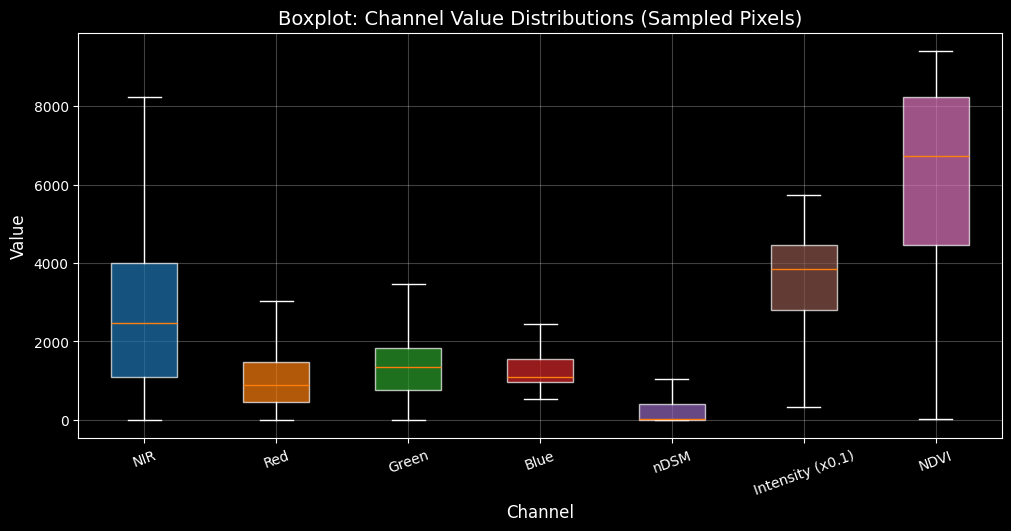

In [21]:
# Descriptive statistics for full images (no tiles)

n_channels = image_arrays[img_files[0]].shape[2]

default_names = ["NIR", "Red", "Green", "Blue", "nDSM", "Intensity", "Number_of_Returns", "NDVI"]
channel_names = default_names[:n_channels] + [f"Ch{i+1}" for i in range(len(default_names), n_channels)]

sum_v = np.zeros(n_channels, dtype=np.float64)
sum_sq_v = np.zeros(n_channels, dtype=np.float64)
count_v = np.zeros(n_channels, dtype=np.float64)
min_v = np.full(n_channels, np.inf, dtype=np.float64)
max_v = np.full(n_channels, -np.inf, dtype=np.float64)

sample_per_image = 5000
rng = np.random.default_rng(42)
samples = [[] for _ in range(n_channels)]

for img_file in img_files:
    arr = image_arrays[img_file].transpose(2, 0, 1).astype(np.float32)  # (C, H, W)
    nodata = image_meta[img_file]["nodata"]

    for ch in range(n_channels):
        vals = arr[ch].ravel()
        valid = np.isfinite(vals)
        if nodata is not None:
            valid &= vals != nodata
        vals = vals[valid]

        if vals.size == 0:
            continue

        vals64 = vals.astype(np.float64)
        sum_v[ch] += vals64.sum()
        sum_sq_v[ch] += np.square(vals64).sum()
        count_v[ch] += vals64.size
        min_v[ch] = min(min_v[ch], float(vals64.min()))
        max_v[ch] = max(max_v[ch], float(vals64.max()))

        take = min(sample_per_image, vals64.size)
        idx = rng.choice(vals64.size, size=take, replace=False)
        samples[ch].append(vals64[idx])

means = sum_v / np.maximum(count_v, 1)
vars_ = (sum_sq_v / np.maximum(count_v, 1)) - np.square(means)
stds = np.sqrt(np.clip(vars_, 0, None))

rows = []
for ch in range(n_channels):
    if len(samples[ch]) > 0:
        s = np.concatenate(samples[ch])
        p5, p50, p95 = np.percentile(s, [5, 50, 95])
    else:
        p5 = p50 = p95 = np.nan

    rows.append({
        "channel": channel_names[ch],
        "mean": round(float(means[ch]), 3),
        "std": round(float(stds[ch]), 3),
        "min": float(min_v[ch]) if np.isfinite(min_v[ch]) else np.nan,
        "max": float(max_v[ch]) if np.isfinite(max_v[ch]) else np.nan,
        "p5": float(p5),
        "p50": float(p50),
        "p95": float(p95),
    })

global_stats = pd.DataFrame(rows)

print(f"images={len(img_files)} | channels={n_channels}")
display(global_stats)


# Histogram: include all channels. Scale Intensity for readability.
hist_scale = {"Intensity": 0.1}
hist_channels = []
for ch in range(n_channels):
    cname = channel_names[ch]
    if len(samples[ch]) == 0:
        continue
    vals = np.concatenate(samples[ch]).astype(np.float64)
    scale = hist_scale.get(cname, 1.0)
    vals_plot = vals * scale
    plot_label = f"{cname} (x{scale:g})" if scale != 1.0 else cname
    hist_channels.append((cname, plot_label, vals_plot))

n_plot = len(hist_channels)
if n_plot > 0:
    ncols = 4
    nrows = int(np.ceil(n_plot / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.8 * ncols, 3.8 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    hist_color = CONFIG["PALETTE"][1]
    median_color = CONFIG["PALETTE"][3]

    for i, (cname, plot_label, vals_plot) in enumerate(hist_channels):
        ax = axes[i]
        if cname == "Number_of_Returns":
            vmin = int(np.floor(vals_plot.min()))
            vmax = int(np.ceil(vals_plot.max()))
            bins = np.arange(vmin - 0.5, vmax + 1.5, 1)
        else:
            bins = 80

        ax.hist(vals_plot, bins=bins, color=hist_color, alpha=0.9, edgecolor="white", linewidth=0.4)
        med = np.median(vals_plot)
        ax.axvline(med, color=median_color, linestyle="--", linewidth=1.8, label="Median")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_title(f"{plot_label} Distribution", fontsize=11)
        ax.set_xlabel("Value")
        ax.set_ylabel("Pixel Count")
        ax.grid(True, alpha=0.25)

    for j in range(n_plot, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Channel Distributions (Sampled Pixels)", fontsize=14)
    fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "channel_histograms.png"), bbox_inches="tight", facecolor="auto", dpi=150)
    plt.show()

    # Boxplot: exclude Number_of_Returns, keep Intensity scaled for readability.
    box_exclude = {"Number_of_Returns"}
    box_channels = [(cname, label, vals) for (cname, label, vals) in hist_channels if cname not in box_exclude]

    box_data = [vals for (_, _, vals) in box_channels]
    box_labels = [label for (_, label, _) in box_channels]

    fig, ax = plt.subplots(figsize=(max(10, 1.4 * len(box_data)), 5.2), constrained_layout=True)
    bp = ax.boxplot(box_data, patch_artist=True, tick_labels=box_labels, showfliers=False)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(CONFIG["PALETTE"][i % len(CONFIG["PALETTE"])])
        patch.set_alpha(0.7)
    ax.set_title("Boxplot: Channel Value Distributions (Sampled Pixels)")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="x", rotation=20)
    fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "channel_boxplots.png"), bbox_inches="tight", facecolor="auto", dpi=150)
    plt.show()
else:
    print("No channel samples available for histogram/boxplot.")

## 5) Label Distribution, Class Imbalance, and Boundary Complexity

**Goal:** quantify class frequencies and understand segmentation difficulty.

### Recommended analyses
- Global pixel count per class
- Per-tile class proportions
- Rare-class identification
- Boundary complexity proxies (edge length, fragmentation)

These results are needed to justify loss weighting, sampling strategy, and evaluation metrics.

masks=4 | total_known_pixels=585,387,106 | total_unknown_pixels=10


,class_id,class_name,pixels,pct
0,1,Building,52502310,8.968819
1,2,Impervious_Surface,90428628,15.447663
2,3,Cropland,114760137,19.604145
3,4,Intensive_Culture,33440345,5.712518
4,5,Grassland_Garden,122023950,20.845001
5,6,Tree_Canopy,81306120,13.889291
6,7,Water,85156214,14.546992
7,8,Railway,5769402,0.985570


Rare classes: Railway (0.99%)


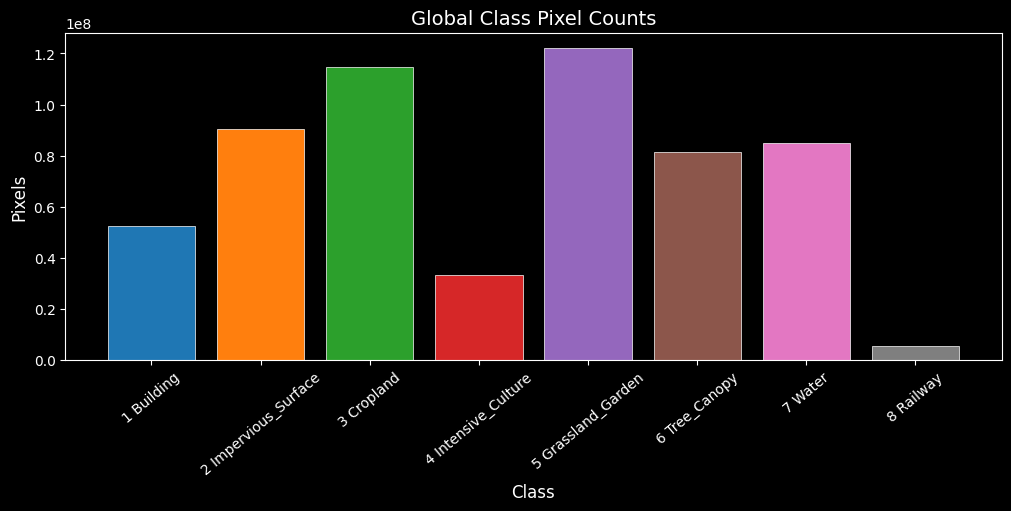

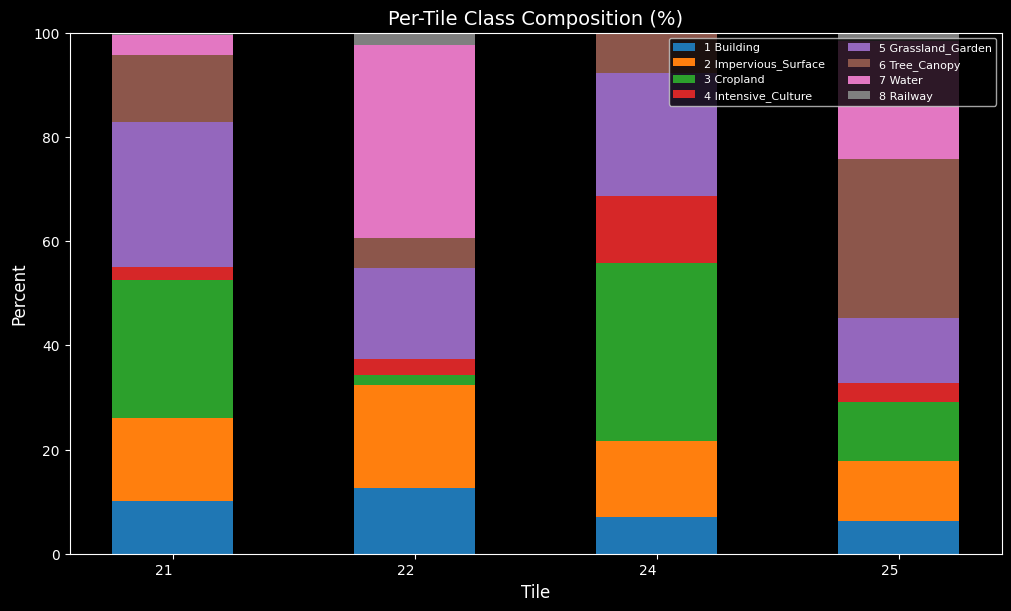

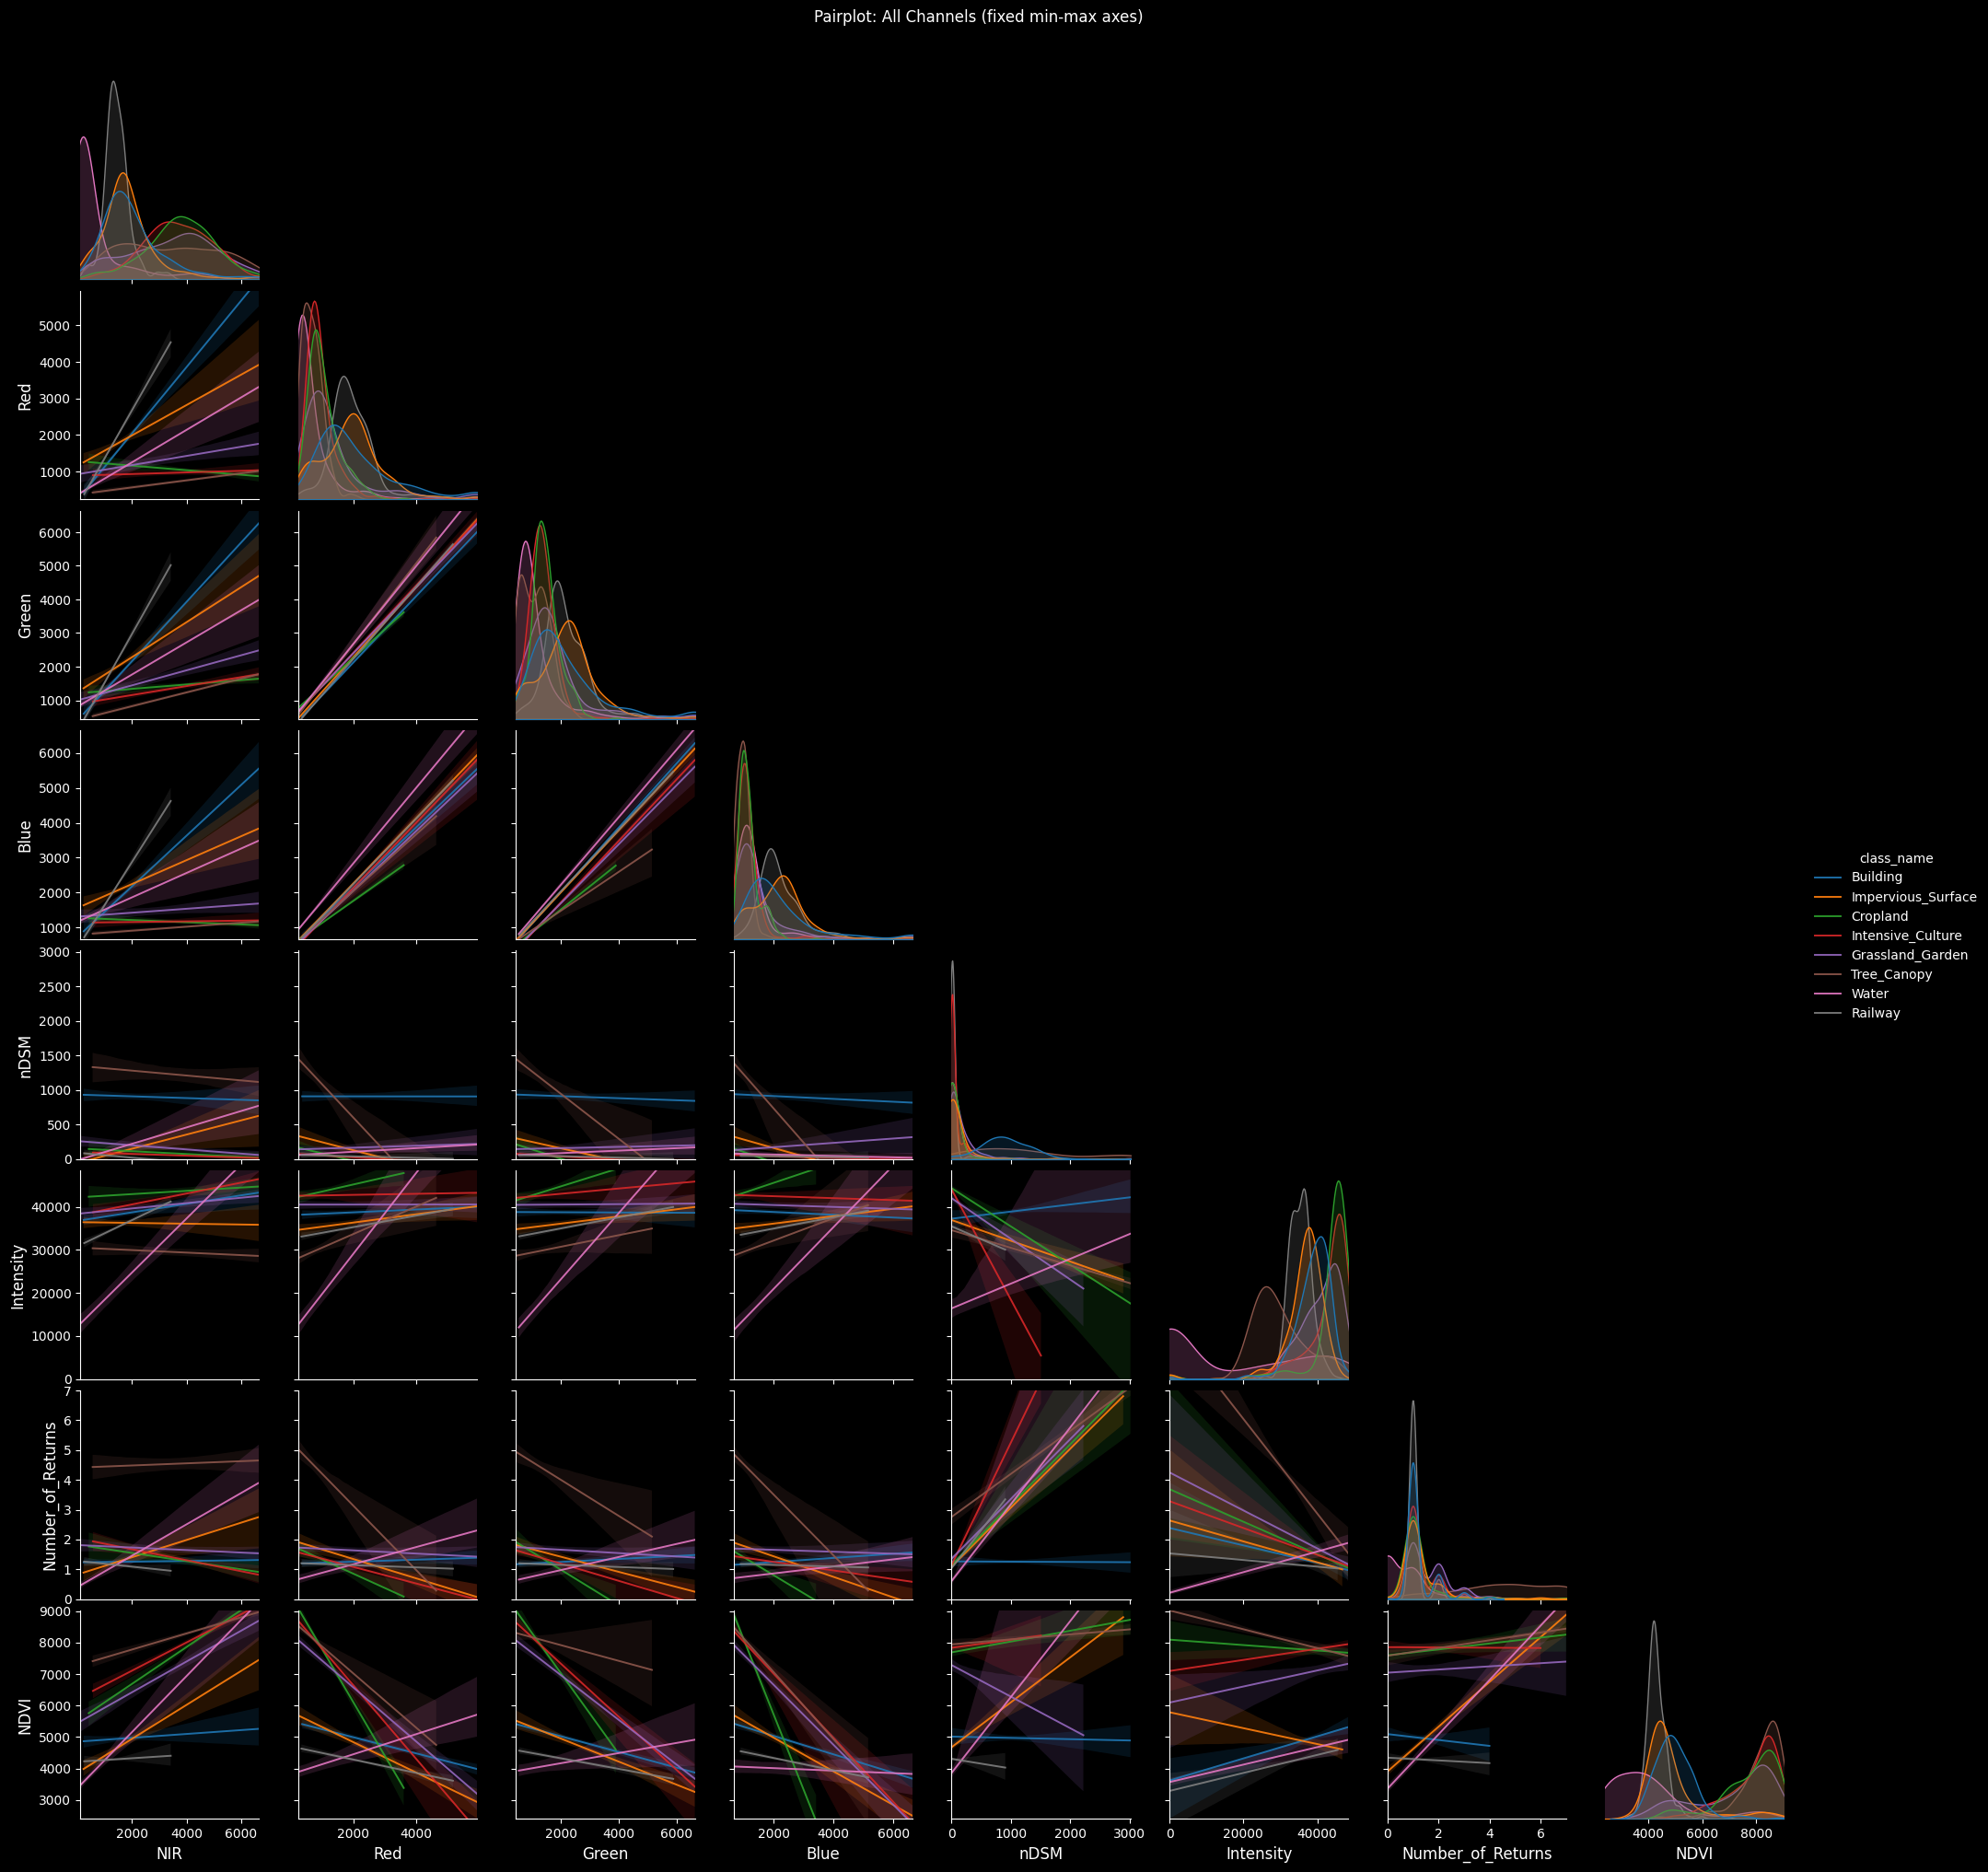

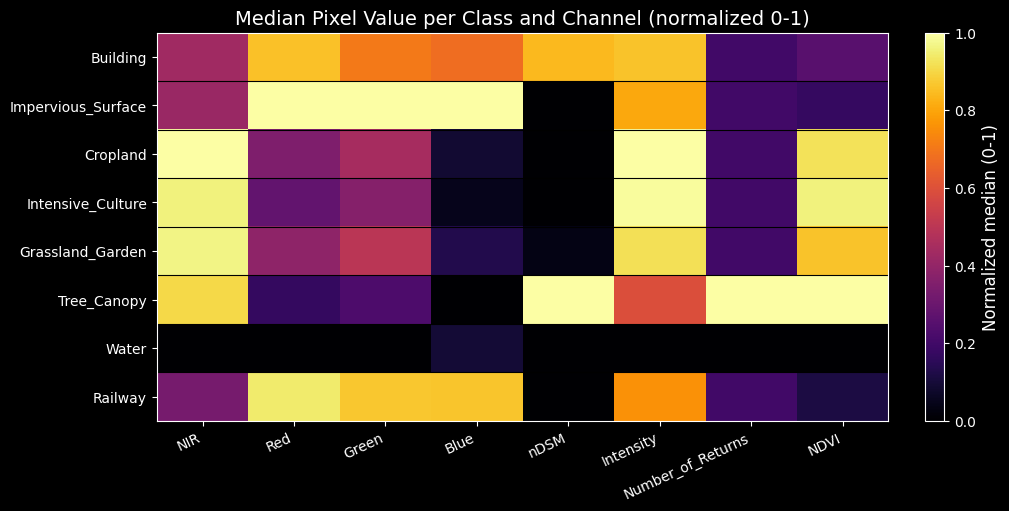

In [32]:
# Label distribution and class imbalance analysis

# NOTE: this cell assumes the shared data-loading cell has been run
# and that `img_files`, `mask_files`, `image_arrays` and `mask_arrays` are available.
# Keep this cell minimal and deterministic — re-run the loader cell if needed.
rng = np.random.default_rng(42)

class_map = CONFIG.get("CLASS_NAMES", {
    1: "Building",
    2: "Impervious_Surface",
    3: "Cropland",
    4: "Intensive_Culture",
    5: "Grassland_Garden",
    6: "Tree_Canopy",
    7: "Water",
    8: "Railway",
})
class_ids = sorted(class_map.keys())
class_name_order = [class_map[cid] for cid in class_ids]
class_cols = [f"class_{cid}" for cid in class_ids]

rows = []
for mf in mask_files:
    with rasterio.open(mf) as src:
        m = src.read(1)

    vals = m[np.isfinite(m)].astype(np.int32)
    u, c = np.unique(vals, return_counts=True)
    cnt = {int(k): int(v) for k, v in zip(u, c)}

    row = {
        "tile_id": tile_id(mf),
        "mask_file": mf,
    }
    for cid in class_ids:
        row[f"class_{cid}"] = cnt.get(cid, 0)

    known_pixels = sum(row[f"class_{cid}"] for cid in class_ids)
    unknown_pixels = int(sum(v for k, v in cnt.items() if k not in class_ids))
    row["known_pixels"] = known_pixels
    row["unknown_pixels"] = unknown_pixels
    row["unknown_pct"] = (100.0 * unknown_pixels / max(known_pixels + unknown_pixels, 1))
    rows.append(row)

per_tile_df = pd.DataFrame(rows).sort_values("tile_id").reset_index(drop=True)

# Global distribution (fixed class order)
global_counts = per_tile_df[class_cols].sum(axis=0)
global_total = int(global_counts.sum())
global_df = pd.DataFrame({
    "class_id": class_ids,
    "class_name": class_name_order,
    "pixels": [int(global_counts[f"class_{cid}"]) for cid in class_ids],
})
global_df["pct"] = 100.0 * global_df["pixels"] / max(global_total, 1)

# Per-tile percentages
for cid in class_ids:
    per_tile_df[f"pct_{cid}"] = 100.0 * per_tile_df[f"class_{cid}"] / np.maximum(per_tile_df["known_pixels"], 1)

# Rare classes (threshold in %)
rare_threshold_pct = 1.0
rare_df = global_df[global_df["pct"] < rare_threshold_pct].copy()

print(f"masks={len(mask_files)} | total_known_pixels={global_total:,} | total_unknown_pixels={int(per_tile_df['unknown_pixels'].sum()):,}")
display(global_df[["class_id", "class_name", "pixels", "pct"]])
if len(rare_df) > 0:
    print("Rare classes:", ", ".join([f"{r.class_name} ({r.pct:.2f}%)" for r in rare_df.itertuples(index=False)]))
else:
    print(f"No rare classes below {rare_threshold_pct}%. ")

# ---- Plot 1: global class counts (linear only, fixed class order) ----
bar_colors = [CONFIG["PALETTE"][(cid - 1) % len(CONFIG["PALETTE"])] for cid in class_ids]
xlabels = [f"{cid} {class_map[cid]}" for cid in class_ids]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.bar(xlabels, global_df["pixels"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_title("Global Class Pixel Counts")
ax.set_xlabel("Class")
ax.set_ylabel("Pixels")
ax.tick_params(axis="x", rotation=40)
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "global_class_counts.png"), bbox_inches="tight", facecolor="auto", dpi=150)

plt.show()

# ---- Plot 2: per-tile stacked class percentages ----
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
bottom = np.zeros(len(per_tile_df), dtype=float)
x = np.arange(len(per_tile_df))

for cid in class_ids:
    vals = per_tile_df[f"pct_{cid}"].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.5,
        label=f"{cid} {class_map[cid]}",
        color=CONFIG["PALETTE"][(cid - 1) % len(CONFIG["PALETTE"])],
    )
    bottom += vals

ax.set_title("Per-Tile Class Composition (%)")
ax.set_xlabel("Tile")
ax.set_ylabel("Percent")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(per_tile_df["tile_id"], ha="right")
ax.legend(ncol=2, fontsize=8, frameon=True)
fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "per_tile_class_composition.png"), bbox_inches="tight", facecolor="auto", dpi=150)

plt.show()

# ---- Plot 3A: class vs pixel values (pairplot across all available channels) ----
image_lookup = {tile_id(p): p for p in img_files}

sample_per_class_per_tile = 350
sample_tables = []

for mf in mask_files:
    tid = tile_id(mf)
    img_path = image_lookup.get(tid)
    if img_path is None:
        continue

    with rasterio.open(mf) as msrc:
        mask = msrc.read(1)
    with rasterio.open(img_path) as isrc:
        img = isrc.read().astype(np.float32)  # (C, H, W)

    n_ch = img.shape[0]
    channel_order = ["NIR", "Red", "Green", "Blue", "nDSM", "Intensity", "Number_of_Returns", "NDVI"]
    ch_names = channel_order[:n_ch]
    if len(ch_names) < n_ch:
        ch_names += [f"Ch{i+1}" for i in range(len(ch_names), n_ch)]

    for cid in class_ids:
        rr, cc = np.where(mask == cid)
        if rr.size == 0:
            continue

        take = min(sample_per_class_per_tile, rr.size)
        idx = rng.choice(rr.size, size=take, replace=False)
        rsel = rr[idx]
        csel = cc[idx]

        vals = img[:, rsel, csel].T
        tmp = pd.DataFrame(vals, columns=ch_names)
        tmp["class_id"] = cid
        tmp["class_name"] = class_map[cid]
        sample_tables.append(tmp)

if len(sample_tables) > 0:
    pair_df = pd.concat(sample_tables, ignore_index=True)
    pair_vars = [c for c in ["NIR", "Red", "Green", "Blue", "nDSM", "Intensity", "Number_of_Returns", "NDVI"] if c in pair_df.columns]

    # Fix class order for all class-based plots
    pair_df["class_name"] = pd.Categorical(pair_df["class_name"], categories=class_name_order, ordered=True)

    if len(pair_vars) >= 2:
        max_rows = 2500
        if len(pair_df) > max_rows:
            pair_df = pair_df.sample(n=max_rows, random_state=42)

        # Readability: clip each channel to [1st, 99th] percentile
        for var in pair_vars:
            lo = np.percentile(pair_df[var], 1)
            hi = np.percentile(pair_df[var], 99)
            pair_df[var] = np.clip(pair_df[var], lo, hi)

        # Explicit min-max limits for each variable after clipping.
        var_limits = {var: (float(pair_df[var].min()), float(pair_df[var].max())) for var in pair_vars}

        g = sns.pairplot(
            data=pair_df,
            vars=pair_vars,
            kind="reg",
            hue="class_name",
            hue_order=class_name_order,
            corner=True,
            plot_kws={
                "scatter": False,
                "line_kws": {"linewidth": 1.4, "alpha": 0.9},
            },
            diag_kind="kde",
            diag_kws={"fill": True, "alpha": 0.20, "linewidth": 1.0, "common_norm": False},
        )

        # Apply fixed min/max limits to each subplot axis.
        for i, y_var in enumerate(pair_vars):
            for j, x_var in enumerate(pair_vars):
                ax = g.axes[i, j]
                if ax is None:
                    continue
                ax.set_xlim(var_limits[x_var])
                if i != j:
                    ax.set_ylim(var_limits[y_var])

        g.fig.suptitle("Pairplot: All Channels (fixed min-max axes)", y=1.02)
        g.fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "class_vs_pixel_pairplot.png"), bbox_inches="tight", facecolor="auto", dpi=150)
        plt.show()

        # ---- Plot 3B: class-wise median heatmap (normalized per-channel for comparability) ----
        heat_vars = [c for c in ["NIR", "Red", "Green", "Blue", "nDSM", "Intensity", "Number_of_Returns", "NDVI"] if c in pair_df.columns]
        med = pair_df.groupby("class_name", observed=False)[heat_vars].median().reindex(class_name_order)

        med_plot = med.copy()
        # Min-max normalize each column (channel) across classes so large-range channels
        # like nDSM or Intensity don't dominate the colormap. This yields values in [0,1].
        med_norm = (med_plot - med_plot.min()) / (med_plot.max() - med_plot.min())
        med_norm = med_norm.fillna(0.0)

        fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
        im = ax.imshow(med_norm.values, aspect="auto", cmap="inferno", vmin=0, vmax=1)
        ax.set_title("Median Pixel Value per Class and Channel (normalized 0-1)")
        ax.set_xticks(np.arange(len(heat_vars)))
        ax.set_xticklabels(heat_vars, rotation=25, ha="right")
        ax.set_yticks(np.arange(len(med_norm.index)))
        ax.set_yticklabels(med_norm.index)
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Normalized median (0-1)")
        
        # Add horizontal lines to separate classes
        for i in range(len(med_norm) - 1):
            ax.axhline(y=i + 0.5, color="black", linewidth=0.8)
        
        fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "class_vs_pixel_median_heatmap_normalized.png"), bbox_inches="tight", facecolor="auto", dpi=150)

        plt.show()
else:
    print("No paired image-mask samples available for class-vs-pixel plots.")

## 6) Missing Data, NoData, and Invalid Value Analysis

**Goal:** identify missing, invalid, or suspicious values that may destabilize training.

### Recommended checks
- NoData proportion per channel and per tile
- NaN/Inf counts
- Out-of-range values
- Mask values outside valid class IDs
- Spatial concentration of invalid pixels

Summarize problematic tiles in a dedicated quality-issue table.

In [23]:
# ================================================
# Implement missing/NoData/invalid-value analysis
# ================================================

issue_records = []
MAX_PLOTS = 5
plots_generated = 0

for idx, row in pair_df.iterrows():
    if not row.get("is_readable", False):
        continue

    tile_id = row["tile_id"]
    img_path = row["image_file"]
    mask_path = row["mask_file"]

    # --- 1. Image Analysis (NaN, Inf, NoData, Ranges) ---
    with rasterio.open(img_path) as src_img:
        img_data = src_img.read()
        nodata_val = src_img.nodata
        
        # NaN and Inf checks
        nan_mask = np.isnan(img_data)
        inf_mask = np.isinf(img_data)
        nan_count = np.sum(nan_mask)
        inf_count = np.sum(inf_mask)

        if nan_count > 0:
            issue_records.append({"tile_id": tile_id, "issue_type": "NaN_in_image", "affected_pixels": nan_count, "severity": "High"})
        if inf_count > 0:
            issue_records.append({"tile_id": tile_id, "issue_type": "Inf_in_image", "affected_pixels": inf_count, "severity": "High"})

        # NoData checks
        if nodata_val is not None:
            nodata_mask = (img_data == nodata_val)
            nodata_count = np.sum(nodata_mask)
            if nodata_count > 0:
                issue_records.append({"tile_id": tile_id, "issue_type": "NoData_in_image", "affected_pixels": nodata_count, "severity": "Medium"})

        # Impossible values check (e.g., negative values in optical/height bands)
        negative_mask = (img_data < 0)
        negative_count = np.sum(negative_mask)
        if negative_count > 0:
            issue_records.append({"tile_id": tile_id, "issue_type": "Negative_values", "affected_pixels": negative_count, "severity": "High"})

    # --- 2. Mask Validation (IDs < 1 or > 8) ---
    with rasterio.open(mask_path) as src_mask:
        mask_data = src_mask.read(1)
        
        # Assuming classes are strictly 1 to 8 based on previous definitions
        invalid_mask = (mask_data < 1) | (mask_data > 8)
        invalid_mask_count = np.sum(invalid_mask)

        if invalid_mask_count > 0:
            issue_records.append({"tile_id": tile_id, "issue_type": "Invalid_mask_IDs", "affected_pixels": invalid_mask_count, "severity": "Critical"})

            # --- 3. Visualize invalid-value maps ---
            if plots_generated < MAX_PLOTS:
                fig, ax = plt.subplots(figsize=(6, 6))
                ax.imshow(invalid_mask, cmap="Reds", interpolation="none")
                ax.set_title(f"Invalid Mask Pixels: {tile_id}")
                ax.axis("off")
                
                plot_path = os.path.join(CONFIG["OUTPUT_DIR"], f"invalid_mask_{tile_id}.png")
                plt.savefig(plot_path, bbox_inches="tight", facecolor="auto", dpi=150)
                plt.close(fig)
                plots_generated += 1

# --- 4. Save issue log ---
issue_df = pd.DataFrame(issue_records)

if not issue_df.empty:
    log_path = os.path.join(CONFIG["OUTPUT_DIR"], "data_issue_log.csv")
    issue_df.to_csv(log_path, index=False)
    print(f"Data validation complete. Found {len(issue_df)} issues.")
    print(f"Issue log saved to: {log_path}")
    display(issue_df.sort_values(by="affected_pixels", ascending=False).head(10))
else:
    print("Data validation complete. No NaN, Inf, NoData, or invalid values detected.")

Data validation complete. No NaN, Inf, NoData, or invalid values detected.


## 7) Correlation Matrix and Feature Redundancy

**Goal:** quantify inter-channel relationships and identify redundant signals.

### Recommended analyses
- Pearson and Spearman correlation on sampled pixels
- Correlation by class (optional)
- Correlation by tile (optional)
- Multicollinearity diagnostics (e.g., VIF on engineered features)

Use stratified pixel sampling to avoid class-dominance bias.

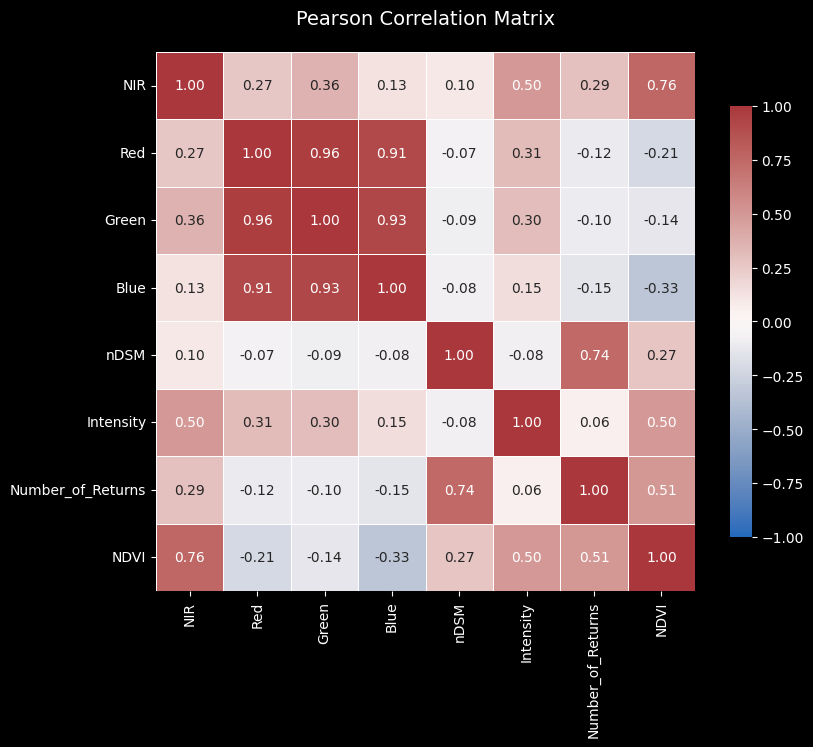

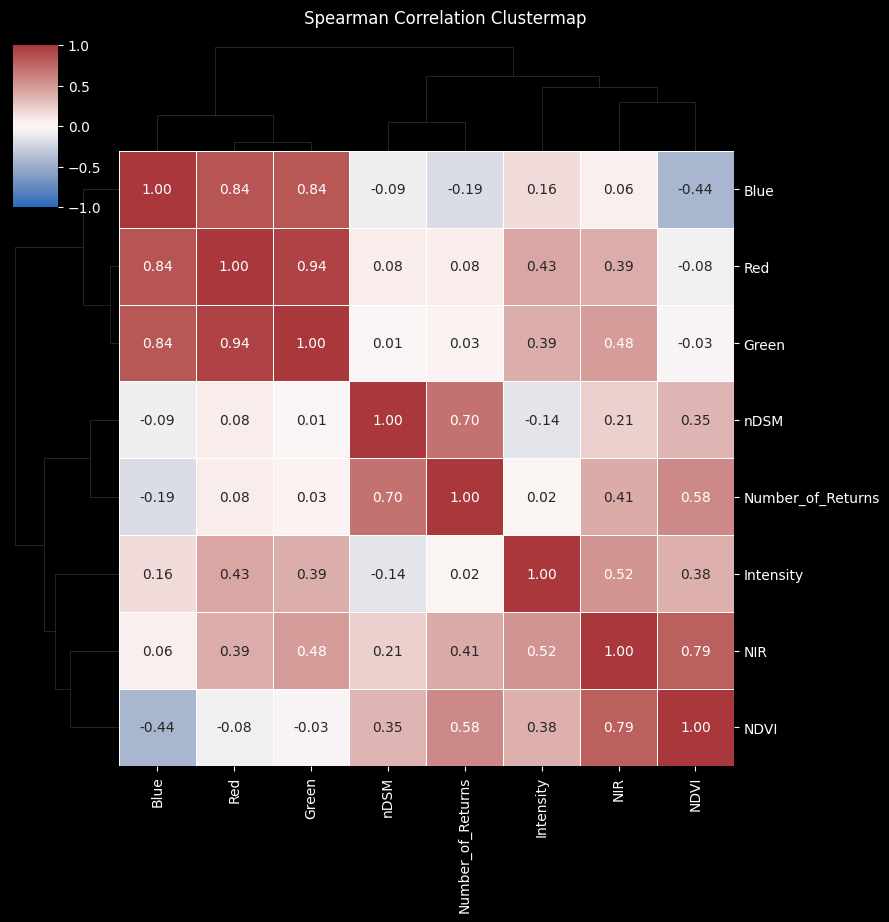


Variance Inflation Factor (VIF):


,Feature,VIF
0,NIR,5.783869
1,Red,19.404364
2,Green,30.632267
3,Blue,11.237969
4,nDSM,2.451957
5,Intensity,2.189443
6,Number_of_Returns,2.998301
7,NDVI,7.515157


In [24]:
# ================================================
# Implement correlation analysis (In-Memory)
# ================================================

CHANNELS = ["NIR", "Red", "Green", "Blue", "nDSM", "Intensity", "Number_of_Returns", "NDVI"]
sampled_features = []

# Calculate sample sizes per image
num_images = len(image_arrays)
if num_images > 0:
    samples_per_tile = max(1, CONFIG["SAMPLE_SIZE"] // num_images)
else:
    samples_per_tile = 0

# --- 1. Sample pixels directly from memory cache ---
for path, arr_hwc in image_arrays.items():
    meta = image_meta[path]
    nodata_val = meta.get("nodata")

    # Flatten array from (H, W, C) to (N_pixels, C)
    H, W, C = arr_hwc.shape
    img_flat = arr_hwc.reshape(H * W, C)

    # Filter invalid pixels (NaN, Inf)
    valid_mask = ~np.isnan(img_flat).any(axis=1) & ~np.isinf(img_flat).any(axis=1)

    # Filter NoData values if defined in metadata
    if nodata_val is not None:
        valid_mask &= (img_flat != nodata_val).all(axis=1)

    img_valid = img_flat[valid_mask]

    # Random sampling to enforce memory constraints
    if len(img_valid) > samples_per_tile:
        indices = np.random.choice(len(img_valid), samples_per_tile, replace=False)
        img_sampled = img_valid[indices]
    else:
        img_sampled = img_valid

    # Keep all channels (8: NIR, R, G, B, nDSM, Intensity, NoR, NDVI)
    if len(img_sampled) > 0:
        sampled_features.append(img_sampled)

# --- 2. Build feature table ---
if sampled_features:
    feature_array = np.vstack(sampled_features)
    df_features = pd.DataFrame(feature_array, columns=CHANNELS)

    # --- 3. Compute correlation matrices ---
    corr_pearson = df_features.corr(method="pearson")
    corr_spearman = df_features.corr(method="spearman")

    # --- 4. Visualize correlations ---
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        corr_pearson,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title("Pearson Correlation Matrix", pad=20)
    fig.savefig(
        os.path.join(CONFIG["OUTPUT_DIR"], "correlation_pearson.png"),
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

    g = sns.clustermap(
        corr_spearman,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        figsize=(9, 9),
        linewidths=0.5,
        dendrogram_ratio=0.15,
    )
    g.fig.suptitle("Spearman Correlation Clustermap", y=1.02)
    g.savefig(
        os.path.join(CONFIG["OUTPUT_DIR"], "correlation_spearman_clustered.png"),
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

    # --- 5. Export correlation tables ---
    corr_pearson.to_csv(os.path.join(CONFIG["OUTPUT_DIR"], "correlation_pearson.csv"))
    corr_spearman.to_csv(os.path.join(CONFIG["OUTPUT_DIR"], "correlation_spearman.csv"))

    # --- 6. (Optional) Compute VIF for redundancy diagnostics ---
    try:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        import statsmodels.api as sm

        X = sm.add_constant(df_features)
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)

        print("\nVariance Inflation Factor (VIF):")
        display(vif_data)
        vif_data.to_csv(os.path.join(CONFIG["OUTPUT_DIR"], "vif_diagnostics.csv"), index=False)

    except ImportError:
        print("\n[Notice] 'statsmodels' not installed. Skipping VIF computation.")
else:
    print("No valid pixels sampled for correlation analysis.")

## 8) Feature Importance for Segmentation-Relevant Signals

**Goal:** estimate which channels/features drive predictive performance.

Because segmentation is spatial and non-linear, use multiple complementary methods.

### Recommended methods
1. **Classical baseline (tabular proxy):** Random Forest on sampled pixels/features
2. **Permutation importance (model-based):** permute channels and measure metric drop
3. **Explainability methods:** SHAP or gradient-based attribution on selected patches

Report global and class-specific importance whenever possible.

Feature matrix shape: (2500, 8) (samples x features)
Target classes: [1 2 3 4 5 6 7 8]
Class distribution:
[  0 328 320 306 335 311 316 289 295]

Training Random Forest...

Train accuracy: 0.8443
Test accuracy: 0.6336

Classification Report:
                    precision    recall  f1-score   support

          Building       0.87      0.91      0.89        82
Impervious_Surface       0.61      0.54      0.57        80
          Cropland       0.46      0.57      0.51        76
 Intensive_Culture       0.47      0.49      0.48        84
  Grassland_Garden       0.39      0.35      0.37        78
       Tree_Canopy       0.70      0.77      0.73        79
             Water       0.98      0.74      0.84        72
           Railway       0.70      0.72      0.71        74

          accuracy                           0.63       625
         macro avg       0.65      0.63      0.64       625
      weighted avg       0.64      0.63      0.63       625


Tree-based Feature Importances:
  

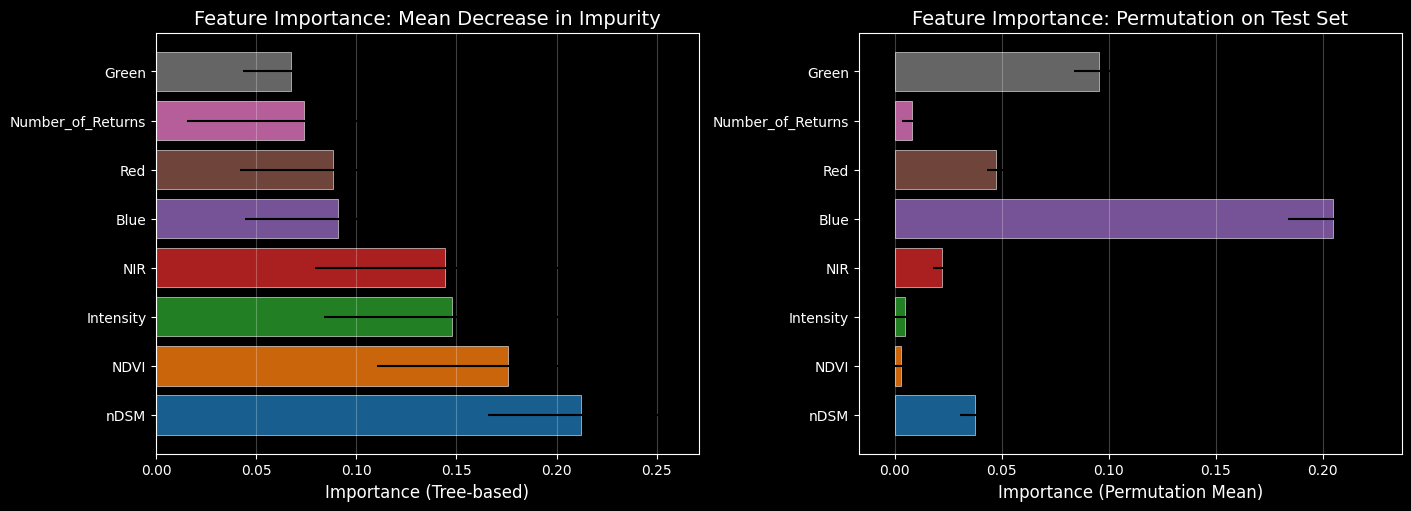

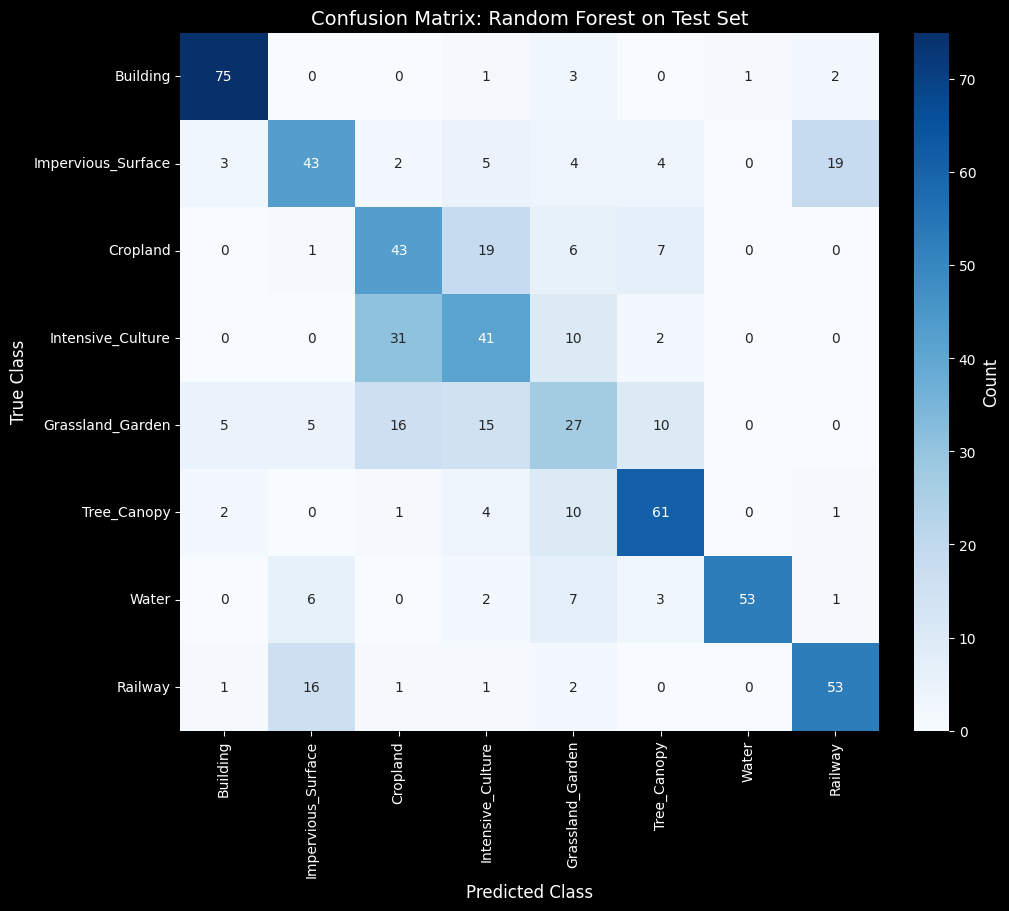


✓ Feature importance analysis complete.
Outputs saved to ./reports/figures
  - feature_importance_table.csv
  - feature_importance_barplot.png
  - feature_importance_confusion_matrix.png


In [34]:
# ================================================
# Feature Importance Analysis (Tabular Proxy + Random Forest)
# ================================================

# NOTE: this cell assumes pair_df from the label distribution cell is available
# (includes sampled pixels per class with feature values and class labels)

if 'pair_df' not in locals() or len(pair_df) == 0:
    print("[Notice] pair_df not available. Skipping feature importance analysis.")
else:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report, confusion_matrix
    
    # --- 1. Prepare feature matrix and target ---
    feature_cols = [c for c in ["NIR", "Red", "Green", "Blue", "nDSM", "Intensity", "Number_of_Returns", "NDVI"] 
                    if c in pair_df.columns]
    
    X = pair_df[feature_cols].values.astype(np.float32)
    y = pair_df["class_id"].values.astype(np.int32)
    
    # Handle any remaining NaN/Inf
    valid_mask = np.isfinite(X).all(axis=1)
    X = X[valid_mask]
    y = y[valid_mask]
    
    print(f"Feature matrix shape: {X.shape} (samples x features)")
    print(f"Target classes: {np.unique(y)}")
    print(f"Class distribution:\n{np.bincount(y)}")
    
    # --- 2. Train/test split (stratified) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    
    # --- 3. Train Random Forest ---
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    
    print("\nTraining Random Forest...")
    rf.fit(X_train, y_train)
    
    # --- 4. Evaluate on test set ---
    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)
    print(f"\nTrain accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    
    y_pred = rf.predict(X_test)
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=class_name_order)}")
    
    # --- 5. Extract feature importances (tree-based) ---
    importances_tree = rf.feature_importances_
    importances_tree_std = np.std(
        [tree.feature_importances_ for tree in rf.estimators_], 
        axis=0
    )
    
    fi_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_tree": importances_tree,
        "std_tree": importances_tree_std,
    }).sort_values("importance_tree", ascending=False).reset_index(drop=True)
    
    print(f"\nTree-based Feature Importances:\n{fi_df}")
    
    # --- 6. Compute permutation importance (optional, slower) ---
    try:
        from sklearn.inspection import permutation_importance
        
        print("\nComputing permutation importance (on test set)...")
        perm_result = permutation_importance(
            rf, X_test, y_test, 
            n_repeats=10, 
            random_state=42, 
            n_jobs=-1
        )
        
        fi_df["importance_perm"] = perm_result.importances_mean
        fi_df["std_perm"] = perm_result.importances_std
        
        print(f"Permutation Feature Importances:\n{fi_df[['feature', 'importance_perm', 'std_perm']]}")
    except Exception as e:
        print(f"[Notice] Permutation importance computation skipped: {e}")
        fi_df["importance_perm"] = np.nan
        fi_df["std_perm"] = np.nan
    
    # --- 7. Visualization: stacked bar chart ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    
    # Tree-based importances
    ax = axes[0]
    colors = [CONFIG["PALETTE"][i % len(CONFIG["PALETTE"])] for i in range(len(fi_df))]
    ax.barh(fi_df["feature"], fi_df["importance_tree"], xerr=fi_df["std_tree"], 
            color=colors, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Importance (Tree-based)")
    ax.set_title("Feature Importance: Mean Decrease in Impurity")
    ax.grid(True, alpha=0.25, axis="x")
    
    # Permutation importances
    ax = axes[1]
    if not fi_df["importance_perm"].isna().all():
        ax.barh(fi_df["feature"], fi_df["importance_perm"], xerr=fi_df["std_perm"], 
                color=colors, alpha=0.8, edgecolor="white", linewidth=0.5)
        ax.set_xlabel("Importance (Permutation Mean)")
        ax.set_title("Feature Importance: Permutation on Test Set")
        ax.grid(True, alpha=0.25, axis="x")
    else:
        ax.text(0.5, 0.5, "Permutation importance not available", 
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
    
    fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "feature_importance_barplot.png"), 
                bbox_inches="tight", facecolor="auto", dpi=150)
    plt.show()
    
    # --- 8. Export results ---
    fi_df.to_csv(os.path.join(CONFIG["OUTPUT_DIR"], "feature_importance_table.csv"), index=False)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_ids)
    cm_df = pd.DataFrame(cm, index=class_name_order, columns=class_name_order)
    
    fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True, ax=ax, 
                cbar_kws={"label": "Count"})
    ax.set_title("Confusion Matrix: Random Forest on Test Set")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    fig.savefig(os.path.join(CONFIG["OUTPUT_DIR"], "feature_importance_confusion_matrix.png"), 
                bbox_inches="tight", facecolor="auto", dpi=150)
    plt.show()
    
    print("\n✓ Feature importance analysis complete.")
    print(f"Outputs saved to {CONFIG['OUTPUT_DIR']}")
    print(f"  - feature_importance_table.csv")
    print(f"  - feature_importance_barplot.png")
    print(f"  - feature_importance_confusion_matrix.png")

## 9) Split Strategy, Leakage Checks, and Distribution Shift

**Goal:** ensure train/validation/test splits are independent and representative.

### Recommended checks
- No tile overlap across splits
- No spatial-neighbor leakage (if overlap buffers exist)
- Similar class distribution across splits
- Similar channel statistics across splits
- Temporal/flight-path grouping consistency (if available)

A good split is as important as model architecture for trustworthy evaluation.

In [26]:
# ================================================
# TODO: Implement split-quality and leakage checks
# ================================================

## TODO: Define or load split assignment
## - train/val/test by tile_id or spatial group

## TODO: Verify strict separation
## - no duplicated tile IDs across splits
## - no overlapping raster footprints across splits (if relevant)

## TODO: Compare distributions per split
## - class frequencies
## - channel means/std
## - optional statistical tests (KS, chi-square)

## TODO: Visualize split differences
## - side-by-side bar plots and density plots

## TODO: Save split quality report
## Include leakage flags and recommended fixes if needed

## 10) Robustness Checks (Augmentation and Domain Shift Readiness)

**Goal:** evaluate whether preprocessing and augmentation plans are aligned with real data variability.

### Recommended checks
- Simulate realistic intensity and geometric perturbations
- Check class stability under perturbations
- Verify that rare classes remain visible after augmentation
- Identify channels most sensitive to perturbation

Document augmentation limits to avoid unrealistic transformations.

In [27]:
# ================================================
# TODO: Implement robustness and augmentation checks
# ================================================

## TODO: Define a small perturbation benchmark
## Examples: brightness shift, contrast shift, mild blur, noise, geometric transforms

## TODO: Measure distribution changes after perturbation
## - channel statistics before/after
## - class visibility and boundary integrity

## TODO: Assess potential augmentation risks
## - unrealistic artifacts
## - class confusion introduced by augmentation

## TODO: Document safe augmentation ranges
## Produce a concise recommendation table for training config

## 11) Outlier Mining and Hard-Case Discovery

**Goal:** identify tiles/pixels that are likely to fail during model training or inference.

### Recommended analyses
- Tiles with extreme channel statistics
- Tiles with unusual class composition
- High boundary complexity or noisy labels
- Potential geolocation misalignment indicators

Use this section to define a manual review shortlist.

In [28]:
# ================================================
# TODO: Implement outlier and hard-case analysis
# ================================================

## TODO: Build tile-level feature summary
## - channel stats, class ratios, texture proxies, invalid-pixel rates

## TODO: Run unsupervised outlier scoring
## Examples: Isolation Forest, Local Outlier Factor, robust z-scores

## TODO: Rank and inspect top-N outlier tiles
## - visualize image/mask overlays
## - document potential root causes

## TODO: Create a manual review list
## Include tile_id, reason_for_review, recommended_action

## 12) Final Model-Readiness Report

**Goal:** turn analysis outputs into actionable decisions for training.

### Include in your final summary
- Data strengths and known weaknesses
- Confirmed risks and mitigation plan
- Recommended preprocessing and normalization
- Recommended split strategy
- Recommended loss/weighting strategy for imbalance
- Priority list for manual relabeling/review

This section should be concise, evidence-based, and reproducible.

In [29]:
# ================================================
# TODO: Write final recommendations and export artifacts
# ================================================

## TODO: Consolidate key metrics and findings
## - integrity pass/fail summary
## - imbalance summary
## - correlation and redundancy summary
## - feature importance summary

## TODO: Produce a final recommendation table
## Columns example: topic, finding, risk_level, recommended_action, priority

## TODO: Export final report assets
## - final_data_analysis_summary.md
## - final_recommendations.csv
## - figures/ and tables/ folders

## TODO: Add open questions and next actions for model development